In [ ]:
# ==========================================
# ENVIRONMENT SETUP
# ==========================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

def find_project_root(markers=(".git", "pyproject.toml", "src")):
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if any((parent / marker).exists() for marker in markers):
            return parent
    raise RuntimeError("Project root not found.")

project_root = str(find_project_root())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from experiments.scripts.EXP_016_MP_SIGNAL_RECOVERY_HEAVY_TAILS import exp_016_mp_signal_recovery_heavy_tails

In [ ]:
# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    "n": 400,
    "p": 200,
    "k_true": 3,
    "df": 3,
    "m": 200,
    "seed": 42
}

In [4]:
# ==========================================
# RUN EXPERIMENT
# ==========================================
print("Executing Signal Recovery & Spike-Bulk Interaction Duel...")
output = exp_016_mp_signal_recovery_heavy_tails(**CONFIG)

results = output["results"]
meta = output["meta"]

Executing Signal Recovery & Spike-Bulk Interaction Duel...


Scenario: heavy_tail: 100%|██████████| 200/200 [00:02<00:00, 69.71it/s]


In [ ]:
# ==========================================
# METADATA
# ==========================================
print("=" * 60)
print(" EXPERIMENT 016: SIGNAL RECOVERY & SPIKE-BULK INTERACTION")
print("=" * 60)

print("\n=== METADATA ===")
for k, v in meta.items():
    print(f"{k}: {v}")

 EXPERIMENT 016: SIGNAL RECOVERY & SPIKE-BULK INTERACTION

=== METADATA ===
n: 400
p: 200
k_true: 3
m: 200
df: 3
execution_time_minutes: 0.2


In [ ]:
# ==========================================
# DIAGNOSTICS
# ==========================================
print("=" * 60)
print(" EXPERIMENT 016: SIGNAL RECOVERY & SPIKE-BULK INTERACTION")
print("=" * 60)

print("\n=== DETECTION MAGNITUDE (MEAN SPIKES) ===")
df_summary = pd.DataFrame({
    "Noise Scenario": ["Gaussian (H0)", "Heavy Tail Elliptical (df=3)"],
    "Pearson Mean (k)": [results["gaussian"]["pearson_mean"], results["heavy_tail"]["pearson_mean"]],
    "Tyler Mean (k)": [results["gaussian"]["tyler_mean"], results["heavy_tail"]["tyler_mean"]]
})
display(df_summary)

print("\n=== HEAVY TAIL DISTRIBUTION ===")
print("Tyler k_effective Distribution:")
df_t = pd.DataFrame.from_dict(results["heavy_tail"]["tyler_dist"], orient='index', columns=['Count (Tyler)'])
display(df_t)

 EXPERIMENT 016: SIGNAL RECOVERY & SPIKE-BULK INTERACTION

=== DETECTION MAGNITUDE (MEAN SPIKES) ===


,Noise Scenario,Pearson Mean (k),Tyler Mean (k)
0,Gaussian (H0),29.855,3.340
1,Heavy Tail Elliptical (df=3),64.635,3.975



=== HEAVY TAIL DISTRIBUTION ===
Tyler k_effective Distribution:


,Count (Tyler)
3,44
4,119
5,35
6,2


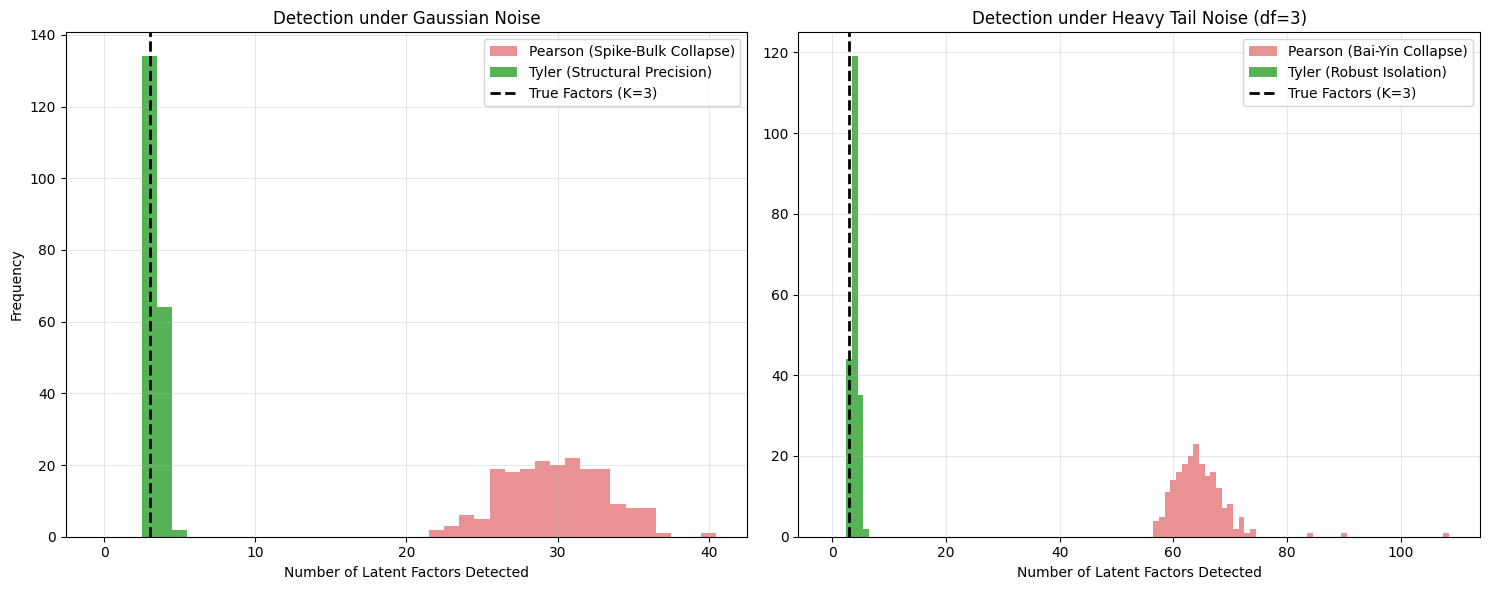

In [ ]:
# ==========================================
# VISUALIZATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

k_true = meta["k_true"]

# --- Panel 1: Gaussian Scenario ---
p_gauss = np.array(results["gaussian"]["raw_k_pearson"])
t_gauss = np.array(results["gaussian"]["raw_k_tyler"])
max_g = max(p_gauss.max(), t_gauss.max())
bins_g = np.arange(max_g + 2) - 0.5

ax1.hist(p_gauss, bins=bins_g, alpha=0.5, label='Pearson (Spike-Bulk Collapse)', color='tab:red')
ax1.hist(t_gauss, bins=bins_g, alpha=0.8, label='Tyler (Structural Precision)', color='tab:green')
ax1.axvline(k_true, color='black', linestyle='--', linewidth=2, label=f'True Factors (K={k_true})')
ax1.set_title("Detection under Gaussian Noise")
ax1.set_xlabel("Number of Latent Factors Detected")
ax1.set_ylabel("Frequency")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Panel 2: Heavy Tail Scenario ---
p_ht = np.array(results["heavy_tail"]["raw_k_pearson"])
t_ht = np.array(results["heavy_tail"]["raw_k_tyler"])
max_ht = max(p_ht.max(), t_ht.max())
bins_ht = np.arange(max_ht + 2) - 0.5

ax2.hist(p_ht, bins=bins_ht, alpha=0.5, label='Pearson (Bai-Yin Collapse)', color='tab:red')
ax2.hist(t_ht, bins=bins_ht, alpha=0.8, label='Tyler (Robust Isolation)', color='tab:green')
ax2.axvline(k_true, color='black', linestyle='--', linewidth=2, label=f'True Factors (K={k_true})')
ax2.set_title("Detection under Heavy Tail Noise (df=3)")
ax2.set_xlabel("Number of Latent Factors Detected")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

1. **Theoretical Alignment (Pearson's Double Collapse):** The empirical data visualizes the absolute mathematical failure of classical linear covariance. Pearson suffers a "Double Collapse". Under purely *Gaussian Noise*, it suffers from *Spike-Bulk Interaction*: the massive energy of the $K=3$ true signals artificially distorts the global variance scaling, sinking the theoretical $\lambda_+$ threshold and hallucinating $\approx 29.8$ factors. When *Heavy Tail Noise* is introduced, it suffers a *Bai-Yin Collapse*: the infinite fourth moment shatters the asymptotic limits, pushing the error to an unusable $\approx 64.6$ false factors.

2. **Finite-Sample Mechanics (Tyler's Structural Precision):** Tyler's M-estimator mathematically neutralizes both classical failures via local directional normalization ($x_i / \|x_i\|$). This spatial projection cancels the magnitude of extreme radial shocks (Heavy Tails) while simultaneously ignoring the scaling dominance of the true signals. The green histograms prove this absolute structural superiority: Tyler effortlessly anchors the detection near the true latent subspace, collapsing the massive red error bulks down to a mean detection of $3.34$ (Gaussian) and $3.97$ (Heavy Tails). 

3. **Pipeline Justification (The Bootstrap Imperative):** While Tyler provides mathematically bounded structural containment, the distribution table reveals it is not asymptotically perfect in finite dimensions. Under heavy tails, the rigid spatial constraint causes a slight rightward drift (the algorithm chose $K=4$ factors $119$ times instead of $3$). This residual topological bias proves the final architectural mandate of this framework: robust M-estimators are the only mathematically valid path for factor detection in high-dimensional financial series, but empirical Bootstrap calibration is strictly required to eliminate the final fractional bias and align the detection exactly on the true $K$ line.